x, y of tumor is removed from features

### import

In [17]:
# ── imports ───────────────────────────────────────────────────────────────────
import os, re, json
import numpy as np
import pandas as pd
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

print("[INIT] All imports successful.")

[INIT] All imports successful.


### config

In [18]:
# ── configs ───────────────────────────────────────────────────────────────────
# CSV_PATH     = "../p2/processed_features.csv"
# DATASET_ROOT = "../dataset"
CSV_PATH     = os.path.join('..', 'p2', 'processed_features.csv')
DATASET_ROOT = os.path.join('..', 'dataset')
IMG_SIZE     = 224
BATCH_SIZE   = 32

TUMOR2IDX = {
    'Normal': 0, 'Astrocytoma': 1, 'Ependymoma': 2, 'Glioma': 3,
    'Hemangiopericytoma': 4, 'Meningioma': 5, 'Neurocytoma': 6,
    'Oligodendroglioma': 7, 'Schwannoma': 8, 'Other': 9
}
WEIGHT2IDX = {'T1': 0, 'T2': 1, 'T1C+': 2}

# Columns to use as structured features (fed into model alongside image)
# Dropping: id, file_name, width, height, point_x, point_y, description,
#           tumor_type, weighting, class, tumor_locations,
#           tumor_idx, weight_idx (redundant with one-hot),
#           lesion_offset (non-normalized version)
FEATURE_COLS = (
    ['point_x_norm', 'point_y_norm', 'lesion_offset_norm',
     'is_central', 'is_normal', 'desc_length'] +
    [c for c in [] ]  # filled after CSV load below
)
# Will be finalized after CSV is loaded — see prepare_data_list()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[CONFIG] Device: {DEVICE}")
print(f"[CONFIG] CSV: {CSV_PATH}")
print(f"[CONFIG] Dataset root: {DATASET_ROOT}")

[CONFIG] Device: cuda
[CONFIG] CSV: ../p2/processed_features.csv
[CONFIG] Dataset root: ../dataset


### load csv

In [19]:
# ── load and inspect CSV ──────────────────────────────────────────────────────
def load_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n[CSV] Loading {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"[CSV] Shape: {df.shape}")
    print(f"[CSV] Columns ({len(df.columns)}): {list(df.columns)}")

    # Drop id — not useful
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
        print("[CSV] Dropped column: id")

    # Check missing
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"[CSV] Missing values found:\n{missing.to_string()}")
        df = df.fillna(0)
        print("[CSV] Filled all missing values with 0.")
    else:
        print("[CSV] No missing values.")

    print(f"[CSV] Tumor type distribution:\n{df['tumor_type'].value_counts().to_string()}")
    print(f"[CSV] Weighting distribution:\n{df['weighting'].value_counts().to_string()}")
    return df


df_meta = load_csv(CSV_PATH)

# Dynamically build feature column list from actual CSV columns
LOC_COLS   = [c for c in df_meta.columns if c.startswith('loc_')]
TUMOR_COLS  = [c for c in df_meta.columns if re.match(r'^tumor_[A-Z]', c)]
WEIGHT_COLS = [c for c in df_meta.columns if re.match(r'^weight_[A-Z]', c)]
TFIDF_COLS = [c for c in df_meta.columns if c.startswith('tfidf_')]
NUMERIC_COLS = ['desc_length']

FEATURE_COLS = NUMERIC_COLS + LOC_COLS + TFIDF_COLS
FEATURE_DIM  = len(FEATURE_COLS)

print(f"\n[FEATURES] Numeric      : {len(NUMERIC_COLS)}")
print(f"[FEATURES] Location     : {len(LOC_COLS)}")
print(f"[FEATURES] Tumor one-hot: {len(TUMOR_COLS)}")
print(f"[FEATURES] Weight one-hot: {len(WEIGHT_COLS)}")
print(f"[FEATURES] TF-IDF       : {len(TFIDF_COLS)}")
print(f"[FEATURES] Total feature dim: {FEATURE_DIM}")
print(f"[FEATURES] feature len: {len(FEATURE_COLS)}")
print(f"[FEATURES] feature names: {FEATURE_COLS}")


[CSV] Loading ../p2/processed_features.csv...
[CSV] Shape: (11300, 86)
[CSV] Columns (86): ['id', 'file_name', 'width', 'height', 'point_x', 'point_y', 'description', 'tumor_type', 'weighting', 'class', 'tumor_locations', 'loc_Unspecified', 'loc_anterior_cranial_fossa', 'loc_basal_ganglia', 'loc_brainstem', 'loc_cavernous_sinus', 'loc_centrum_semiovale', 'loc_cerebellopontine_angle', 'loc_clivus', 'loc_corona_radiata', 'loc_falx', 'loc_frontal', 'loc_infratentorial', 'loc_interhemispheric', 'loc_intracanalicular', 'loc_intraventricular', 'loc_middle_cranial_fossa', 'loc_occipital', 'loc_olfactory_groove', 'loc_paraclinoid', 'loc_parafalcine', 'loc_parietal', 'loc_petroclival', 'loc_petrous_ridge', 'loc_pineal', 'loc_planum_sphenoidale', 'loc_posterior_fossa', 'loc_suprasellar', 'loc_supratentorial', 'loc_temporal', 'loc_tentorial', 'loc_trigeminal', 'loc_ventricle', 'loc_vestibular', 'point_x_norm', 'point_y_norm', 'tumor_idx', 'weight_idx', 'tumor_Astrocytoma', 'tumor_Ependymoma', 't

### dataset

In [20]:
# ── dataset ───────────────────────────────────────────────────────────────────
def create_heatmap(shape, center, sigma=5):
    """Gaussian heatmap centered on lesion point. Returns zeros for Normal scans."""
    heatmap = np.zeros(shape, dtype=np.float32)
    if center is None or center[0] == -1:
        return heatmap
    x0, y0 = center
    y, x = np.ogrid[:shape[0], :shape[1]]
    heatmap = np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))
    return heatmap


def get_transforms(train=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))


class BrainMRIDataset(Dataset):
    def __init__(self, data_list, feature_cols, transform=None):
        """
        data_list    : list of dicts with keys:
                       image_path, tumor_label, weight_label, keypoint, features
        feature_cols : list of column names used as structured features
        transform    : albumentations transform
        """
        self.data         = data_list
        self.feature_cols = feature_cols
        self.transform    = transform
        print(f"[DATASET] Initialized with {len(data_list)} samples, "
              f"{len(feature_cols)} feature dims.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = cv2.imread(item['image_path'])

        # Skip corrupted images by trying next
        if image is None:
            print(f"[DATASET][WARN] Could not read: {item['image_path']} — skipping.")
            return self.__getitem__((idx + 1) % len(self.data))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        kp    = item['keypoint']

        if self.transform:
            if kp[0] != -1:
                augmented = self.transform(image=image, keypoints=[kp])
                image     = augmented['image']
                kp        = augmented['keypoints'][0] if augmented['keypoints'] else (-1, -1)
            else:
                augmented = self.transform(image=image, keypoints=[])
                image     = augmented['image']

        # Gaussian heatmap at lesion location
        hmap = create_heatmap((IMG_SIZE, IMG_SIZE), kp)
        hmap = torch.tensor(hmap, dtype=torch.float32).unsqueeze(0)  # (1, H, W)

        # Structured feature vector from CSV
        feat_vec = torch.tensor(item['features'], dtype=torch.float32)  # (FEATURE_DIM,)

        t_label = torch.tensor(TUMOR2IDX[item['tumor_label']], dtype=torch.long)
        w_label = torch.tensor(WEIGHT2IDX[item['weight_label']], dtype=torch.long)

        return image, t_label, w_label, hmap, feat_vec


def prepare_data_list(df: pd.DataFrame, dataset_root: str, feature_cols: list) -> list:
    """
    Reads processed_features.csv rows and builds a list of dicts for the Dataset.
    Constructs the image path from file_name column.
    """
    print(f"\n[PREP] Building data list from CSV ({len(df)} rows)...")
    data_list = []
    skipped   = 0
    skipped_hist = []

    for _, row in df.iterrows():
        # file_name in CSV is like "Astrocytoma T1\T1 - Anaplastic astrocytoma 001.jpg"
        clean_path    = str(row['file_name']).replace('\\', os.sep).replace('/', os.sep)
        full_img_path = os.path.join(dataset_root, clean_path)

        if not os.path.exists(full_img_path):
            skipped += 1
            skipped_hist.append(full_img_path)
            continue

        # Parse weighting — CSV stores T1C+ as T1C+ but WEIGHT2IDX uses T1C+
        raw_class    = str(row['class'])
        weight_label = 'Unknown'
        for w in ['T1C+', 'T2', 'T1']:
            if raw_class.endswith(w):
                weight_label = w
                break

        tumor_label = str(row['tumor_type']).strip()

        # Keypoint: (-1,-1) for Normal so heatmap stays zero
        if tumor_label == 'Normal':
            kp = (-1, -1)
        else:
            kp = (float(row['point_x']), float(row['point_y']))

        # Structured feature vector
        features = row[feature_cols].values.astype(np.float32)

        data_list.append({
            'image_path':  full_img_path,
            'tumor_label': tumor_label,
            'weight_label': weight_label,
            'keypoint':    kp,
            'features':    features,
        })

    print(f"[PREP] Loaded  : {len(data_list)} samples")
    print(f"[PREP] Skipped : {skipped} (image file not found)")
    print(f"[PREP] list of not found images: {skipped_hist}")

    # Sanity check: show label distribution
    from collections import Counter
    tumor_dist = Counter(d['tumor_label'] for d in data_list)
    print(f"[PREP] Tumor distribution:")
    for k, v in sorted(tumor_dist.items()):
        print(f"         {k:<22} {v}")

    return data_list


def get_stratified_loaders(data_list, batch_size=32, test_size=0.2, seed=42):
    stratify_labels = [f"{d['tumor_label']}_{d['weight_label']}" for d in data_list]

    train_data, val_data = train_test_split(
        data_list,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_labels
    )

    print(f"\n[SPLIT] Total  : {len(data_list)}")
    print(f"[SPLIT] Train  : {len(train_data)} ({100*(1-test_size):.0f}%)")
    print(f"[SPLIT] Val    : {len(val_data)} ({100*test_size:.0f}%)")

    train_ds = BrainMRIDataset(train_data, FEATURE_COLS, transform=get_transforms(train=True))
    val_ds   = BrainMRIDataset(val_data,   FEATURE_COLS, transform=get_transforms(train=False))

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)

    print(f"[SPLIT] Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    return train_loader, val_loader

### model

In [21]:
# ── model ─────────────────────────────────────────────────────────────────────

class CustomBrainNet(nn.Module):
    """
    Multi-task CNN with structured feature fusion.

    Image path  : Conv backbone → spatial features → pool → 512-dim vector
    Feature path: structured CSV features → MLP → 64-dim vector
    Fusion      : concat(512, 64) → 576-dim → three heads

    Backbone stages:
      3  →  32  @ 224x224
      32 →  64  @ 112x112  (MaxPool)
      64 → 128  @  56x56   (MaxPool)
     128 → 256  @  28x28   (MaxPool)
     256 → 384  @  14x14   (MaxPool)  ← new
     384 → 512  @  14x14              ← new (no pool — keep spatial for heatmap)

    Heads:
      - tumor_head  : 10-class  (3 linear layers)
      - weight_head :  3-class  (2 linear layers)
      - heatmap_head:  1-channel lesion localization map
    """
    def __init__(self, num_tumor_classes=10, num_weight_classes=3, feature_dim=68):
        super().__init__()
        print(f"[MODEL] CustomBrainNet | tumor={num_tumor_classes} | "
              f"weight={num_weight_classes} | feature_dim={feature_dim}")

        # ── Image backbone ────────────────────────────────────────────────────
        self.features = nn.Sequential(
            # Stage 1: 224x224 → 112x112
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Stage 2: 112x112 → 56x56
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Stage 3: 56x56 → 28x28
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Stage 4: 28x28 → 14x14
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # NEW stage

            # Stage 5: 14x14 → 14x14 (no pool — keep spatial for heatmap)
            nn.Conv2d(256, 512, 3, padding=1),  # NEW stage
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        # backbone output: (B, 512, 14, 14)

        # ── Heatmap decoder ───────────────────────────────────────────────────
        # Upsample 14x14 → 224x224 (scale 16)
        self.heatmap_head = nn.Sequential(
            nn.Conv2d(512, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=16, mode='bilinear', align_corners=True),  # 14→224
            nn.Conv2d(128, 1, 1),
            nn.Sigmoid()
        )

        # ── Global pool ───────────────────────────────────────────────────────
        self.global_pool = nn.AdaptiveAvgPool2d(1)  # (B, 512, 1, 1)

        # ── Structured feature MLP ────────────────────────────────────────────
        self.feature_mlp = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
        )

        # fusion: 512 (image) + 64 (features) = 576
        fusion_dim = 512 + 64

        # ── Tumor head: 3 linear layers ───────────────────────────────────────
        self.tumor_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),     # layer 1
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),            # layer 2  ← new
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_tumor_classes)  # layer 3 — output
        )

        # ── Weight head: 2 linear layers (unchanged) ──────────────────────────
        self.weight_head = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_weight_classes)
        )

        # Print parameter count per component
        def count(module):
            return sum(p.numel() for p in module.parameters() if p.requires_grad)

        print(f"[MODEL] Backbone params    : {count(self.features):,}")
        print(f"[MODEL] Heatmap head params: {count(self.heatmap_head):,}")
        print(f"[MODEL] Feature MLP params : {count(self.feature_mlp):,}")
        print(f"[MODEL] Tumor head params  : {count(self.tumor_head):,}")
        print(f"[MODEL] Weight head params : {count(self.weight_head):,}")
        total = count(self)
        print(f"[MODEL] Total trainable    : {total:,}")

    def forward(self, x, feat_vec):
        # x        : (B, 3, 224, 224)
        # feat_vec : (B, feature_dim)

        spatial    = self.features(x)                               # (B, 512, 14, 14)
        heatmap    = self.heatmap_head(spatial)                     # (B, 1, 224, 224)
        pooled     = self.global_pool(spatial).view(x.size(0), -1) # (B, 512)
        feat_e     = self.feature_mlp(feat_vec)                     # (B, 64)
        fused      = torch.cat([pooled, feat_e], dim=1)             # (B, 576)
        tumor_out  = self.tumor_head(fused)                         # (B, 10)
        weight_out = self.weight_head(fused)                        # (B, 3)

        return tumor_out, weight_out, heatmap

# ── EfficientNet version (commented out — swap model below to use) ────────────
# class MultiTaskBrainModel(nn.Module):
#     """
#     EfficientNet-B0 backbone with structured feature fusion.
#     Swap in by replacing CustomBrainNet(...) with MultiTaskBrainModel(...)
#     in the training cell below.
#     """
#     def __init__(self, num_tumor_classes=10, num_weight_classes=3, feature_dim=68):
#         super().__init__()
#         backbone       = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
#         self.backbone  = backbone.features            # (B, 1280, 7, 7)
#         n_feat         = 1280
#
#         self.feature_mlp = nn.Sequential(
#             nn.Linear(feature_dim, 128), nn.ReLU(), nn.Dropout(0.3),
#             nn.Linear(128, 64),          nn.ReLU(),
#         )
#         fusion_dim = n_feat + 64
#
#         self.heatmap_head = nn.Sequential(
#             nn.Conv2d(n_feat, 256, 3, padding=1), nn.ReLU(),
#             nn.Upsample(scale_factor=32, mode='bilinear', align_corners=True),
#             nn.Conv2d(256, 1, 1), nn.Sigmoid()
#         )
#         self.global_pool = nn.AdaptiveAvgPool2d(1)
#         self.tumor_head  = nn.Sequential(
#             nn.Linear(fusion_dim, 256), nn.ReLU(), nn.Dropout(0.3),
#             nn.Linear(256, num_tumor_classes)
#         )
#         self.weight_head = nn.Sequential(
#             nn.Linear(fusion_dim, 64), nn.ReLU(),
#             nn.Linear(64, num_weight_classes)
#         )
#
#     def forward(self, x, feat_vec):
#         spatial    = self.backbone(x)                          # (B, 1280, 7, 7)
#         heatmap    = self.heatmap_head(spatial)
#         pooled     = self.global_pool(spatial).view(x.size(0), -1)
#         feat_e     = self.feature_mlp(feat_vec)
#         fused      = torch.cat([pooled, feat_e], dim=1)
#         return self.tumor_head(fused), self.weight_head(fused), heatmap

### train

In [22]:
# ── trainer ───────────────────────────────────────────────────────────────────
class BrainTrainer:
    def __init__(self, model, train_loader, val_loader, optimizer, scheduler, device):
        self.model        = model
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.optimizer    = optimizer
        self.scheduler    = scheduler
        self.device       = device

        self.criterion_tumor   = nn.CrossEntropyLoss()
        self.criterion_weight  = nn.CrossEntropyLoss()
        self.criterion_heatmap = nn.MSELoss()
        print(f"[TRAINER] Ready on {device}")

    def train_epoch(self):
        self.model.train()
        total_loss = correct_tumor = total_samples = 0

        pbar = tqdm(self.train_loader, desc="  Train", leave=False)
        for images, t_labels, w_labels, heatmaps, feat_vecs in pbar:
            images    = images.to(self.device)
            t_labels  = t_labels.to(self.device)
            w_labels  = w_labels.to(self.device)
            heatmaps  = heatmaps.to(self.device)
            feat_vecs = feat_vecs.to(self.device)

            self.optimizer.zero_grad()

            out_tumor, out_weight, out_heatmap = self.model(images, feat_vecs)

            loss_t = self.criterion_tumor(out_tumor, t_labels)
            loss_w = self.criterion_weight(out_weight, w_labels)
            loss_h = self.criterion_heatmap(out_heatmap, heatmaps)
            loss   = loss_t + 0.5 * loss_w + 5.0 * loss_h

            loss.backward()
            self.optimizer.step()

            total_loss    += loss.item()
            _, pred        = torch.max(out_tumor, 1)
            correct_tumor += (pred == t_labels).sum().item()
            total_samples += t_labels.size(0)

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc':  f"{100*correct_tumor/total_samples:.1f}%"
            })

        avg_loss = total_loss / len(self.train_loader)
        avg_acc  = 100 * correct_tumor / total_samples
        return avg_loss, avg_acc

    def validate(self):
        self.model.eval()
        val_loss = correct_tumor = total_samples = 0

        with torch.no_grad():
            for images, t_labels, w_labels, heatmaps, feat_vecs in self.val_loader:
                images    = images.to(self.device).float()
                t_labels  = t_labels.to(self.device)
                w_labels  = w_labels.to(self.device)
                heatmaps  = heatmaps.to(self.device).float()
                feat_vecs = feat_vecs.to(self.device)

                out_tumor, out_weight, out_heatmap = self.model(images, feat_vecs)

                loss_t = self.criterion_tumor(out_tumor, t_labels)
                loss_w = self.criterion_weight(out_weight, w_labels)
                loss_h = self.criterion_heatmap(out_heatmap, heatmaps)
                loss   = loss_t + 0.5 * loss_w + 5.0 * loss_h

                val_loss      += loss.item()
                _, pred        = torch.max(out_tumor, 1)
                correct_tumor += (pred == t_labels).sum().item()
                total_samples += t_labels.size(0)

        avg_loss = val_loss / len(self.val_loader)
        avg_acc  = 100 * correct_tumor / total_samples
        return avg_loss, avg_acc

    def evaluate_report(self):
        """Full classification report on val set after training."""
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, t_labels, w_labels, heatmaps, feat_vecs in self.val_loader:
                images    = images.to(self.device)
                feat_vecs = feat_vecs.to(self.device)
                out_tumor, _, _ = self.model(images, feat_vecs)
                _, pred = torch.max(out_tumor, 1)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(t_labels.numpy())

        idx2tumor = {v: k for k, v in TUMOR2IDX.items()}
        names     = [idx2tumor[i] for i in range(len(TUMOR2IDX))]
        print("\n[EVAL] Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=names, zero_division=0))

        cm = confusion_matrix(all_labels, all_preds)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=names, yticklabels=names, ax=ax)
        ax.set_title('Confusion Matrix — Tumor Type')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=150)
        plt.close()
        print("[EVAL] Saved confusion_matrix.png")

### early stopping


In [23]:
# ── early stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=7, path='./models/best_model_v4.pth'):
        self.patience   = patience
        self.path       = path
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            print(f"  [CKPT] Val loss improved → {val_loss:.4f} — model saved.")
            self.counter = 0
        else:
            self.counter += 1
            print(f"  [CKPT] No improvement. Patience: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

### build data

In [24]:
# ── build data ────────────────────────────────────────────────────────────────
data_list = prepare_data_list(df_meta, DATASET_ROOT, FEATURE_COLS)
train_loader, val_loader = get_stratified_loaders(data_list, batch_size=BATCH_SIZE)

# Quick sanity check on one batch
print("\n[SANITY] Checking one batch from train_loader...")
images, t_labels, w_labels, heatmaps, feat_vecs = next(iter(train_loader))
print(f"  images shape   : {images.shape}")       # (32, 3, 224, 224)
print(f"  t_labels shape : {t_labels.shape}")      # (32,)
print(f"  w_labels shape : {w_labels.shape}")      # (32,)
print(f"  heatmaps shape : {heatmaps.shape}")      # (32, 1, 224, 224)
print(f"  feat_vecs shape: {feat_vecs.shape}")     # (32, FEATURE_DIM)
print(f"  feat_vecs sample (first row): {feat_vecs[0][:8].numpy()}")


[PREP] Building data list from CSV (11300 rows)...
[PREP] Loaded  : 11300 samples
[PREP] Skipped : 0 (image file not found)
[PREP] list of not found images: []
[PREP] Tumor distribution:
         Astrocytoma            1118
         Ependymoma             1037
         Glioma                 1476
         Hemangiopericytoma     603
         Meningioma             2071
         Neurocytoma            618
         Normal                 1058
         Oligodendroglioma      550
         Other                  1533
         Schwannoma             1236

[SPLIT] Total  : 11300
[SPLIT] Train  : 9040 (80%)
[SPLIT] Val    : 2260 (20%)
[DATASET] Initialized with 9040 samples, 54 feature dims.
[DATASET] Initialized with 2260 samples, 54 feature dims.
[SPLIT] Train batches: 283 | Val batches: 71

[SANITY] Checking one batch from train_loader...
  images shape   : torch.Size([32, 3, 224, 224])
  t_labels shape : torch.Size([32])
  w_labels shape : torch.Size([32])
  heatmaps shape : torch.Size([32

/home/user/python_envs/ds_projects/lib/python3.14/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### train

In [25]:
# ── train ─────────────────────────────────────────────────────────────────────
model = CustomBrainNet(
    num_tumor_classes=len(TUMOR2IDX),
    num_weight_classes=len(WEIGHT2IDX),
    feature_dim=FEATURE_DIM
).to(DEVICE)

# >>> CHANGED: ADDED WEIGHT RESUMPTION LOGIC HERE <<<
WEIGHTS_PATH = './models/best_model_v4.pth' # or 'best_model.pth' depending on your file name
if os.path.exists(WEIGHTS_PATH):
    print(f"[LOAD] Found existing checkpoint at {WEIGHTS_PATH}. Loading weights for warm start...")
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
    print("[LOAD] Weights loaded successfully. Resuming training...")
else:
    print(f"[LOAD] No checkpoint found at {WEIGHTS_PATH}. Starting training from scratch.")
# >>> END OF CHANGE <<<

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[MODEL] Trainable parameters: {total_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
early_stopper = EarlyStopping(patience=7, path='./models/best_model_v4.pth')
trainer = BrainTrainer(model, train_loader, val_loader, optimizer, scheduler, DEVICE)


[MODEL] CustomBrainNet | tumor=10 | weight=3 | feature_dim=54
[MODEL] Backbone params    : 1,570,560
[MODEL] Heatmap head params: 590,081
[MODEL] Feature MLP params : 15,296
[MODEL] Tumor head params  : 181,898
[MODEL] Weight head params : 37,123
[MODEL] Total trainable    : 2,394,958
[LOAD] Found existing checkpoint at ./models/best_model_v4.pth. Loading weights for warm start...
[LOAD] Weights loaded successfully. Resuming training...
[MODEL] Trainable parameters: 2,394,958
[TRAINER] Ready on cuda


In [ ]:

EPOCHS = 60

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f"\n[TRAIN] Starting training for up to {EPOCHS} epochs...")
print("="*60)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    t_loss, t_acc = trainer.train_epoch()
    v_loss, v_acc = trainer.validate()
    trainer.scheduler.step()
    early_stopper(v_loss, model)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    print(f"  Train — Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  Val   — Loss: {v_loss:.4f} | Acc: {v_acc:.2f}%")

    if early_stopper.early_stop:
        print(f"\n[TRAIN] Early stopping at epoch {epoch}.")
        break

print("\n[TRAIN] Training complete.")

### eval

In [26]:
# ── evaluate ──────────────────────────────────────────────────────────────────
print("[EVAL] Loading best model weights...")
model.load_state_dict(torch.load('./models/best_model_v4.pth', map_location=DEVICE))
trainer.evaluate_report()

[EVAL] Loading best model weights...

[EVAL] Classification Report:
                    precision    recall  f1-score   support

            Normal       0.98      0.99      0.99       212
       Astrocytoma       0.85      0.85      0.85       223
        Ependymoma       0.94      0.89      0.92       208
            Glioma       0.89      0.95      0.92       295
Hemangiopericytoma       0.97      0.90      0.94       121
        Meningioma       0.92      0.92      0.92       414
       Neurocytoma       0.96      0.91      0.93       124
 Oligodendroglioma       0.80      0.80      0.80       109
        Schwannoma       0.89      0.94      0.91       248
             Other       0.91      0.89      0.90       306

          accuracy                           0.91      2260
         macro avg       0.91      0.90      0.91      2260
      weighted avg       0.91      0.91      0.91      2260

[EVAL] Saved confusion_matrix.png


[VIZ] Fetching one batch...
[VIZ] True label: Ependymoma
[VIZ] Feature vector (first 10): [653.   0.   0.   0.   0.   0.   0.   0.   0.   0.]


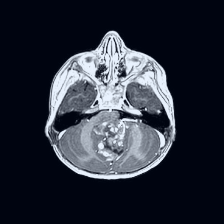

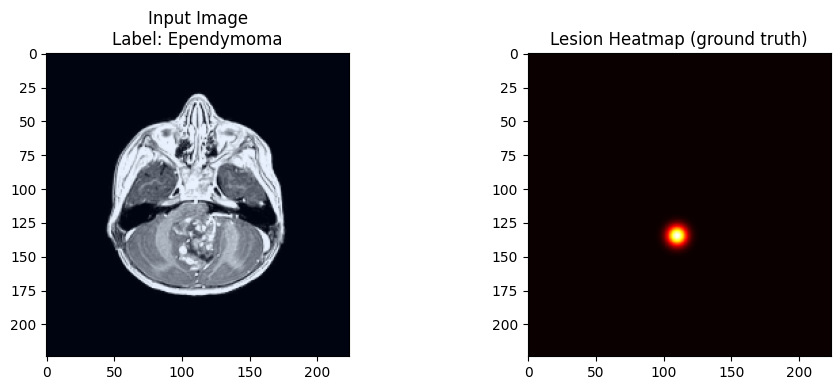

In [27]:
# ── debug visualize (notebook only) ──────────────────────────────────────────
%matplotlib inline

def debug_visualize(model, loader, device):
    model.eval()
    print("[VIZ] Fetching one batch...")
    images, t_labels, w_labels, heatmaps, feat_vecs = next(iter(loader))

    img = images[0].permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255).astype(np.uint8)

    idx2tumor = {v: k for k, v in TUMOR2IDX.items()}
    true_label = idx2tumor[t_labels[0].item()]
    print(f"[VIZ] True label: {true_label}")
    print(f"[VIZ] Feature vector (first 10): {feat_vecs[0][:10].numpy()}")

    display(Image.fromarray(img))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"Input Image\nLabel: {true_label}")
    axes[1].imshow(heatmaps[0, 0].numpy(), cmap='hot')
    axes[1].set_title("Lesion Heatmap (ground truth)")
    plt.tight_layout()
    plt.show()

debug_visualize(model, val_loader, DEVICE)

In [28]:
# ── plot training curves ──────────────────────────────────────────────────────
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs_ran = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=14)

    # Loss
    axes[0].plot(epochs_ran, train_losses, label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(epochs_ran, val_losses,   label='Val Loss',   color='coral',     linewidth=2)
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    best_epoch = val_losses.index(min(val_losses)) + 1
    axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch})')
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs_ran, train_accs, label='Train Acc', color='steelblue', linewidth=2)
    axes[1].plot(epochs_ran, val_accs,   label='Val Acc',   color='coral',     linewidth=2)
    axes[1].set_title('Tumor Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    best_acc_epoch = val_accs.index(max(val_accs)) + 1
    axes[1].axvline(x=best_acc_epoch, color='gray', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_acc_epoch})')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.close()
    print(f"[PLOT] Saved training_curves.png")
    print(f"[PLOT] Best val loss  : {min(val_losses):.4f} at epoch {best_epoch}")
    print(f"[PLOT] Best val acc   : {max(val_accs):.2f}% at epoch {best_acc_epoch}")

plot_training_curves(train_losses, val_losses, train_accs, val_accs)

NameError: name 'train_losses' is not defined

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_curve(model, val_loader, device, num_classes=10):
    model.eval()
    all_preds, all_labels = [], []
    
    print("\n[EVAL] Generating ROC Curves...")
    with torch.no_grad():
        for images, t_labels, w_labels, heatmaps, feat_vecs in tqdm(val_loader, desc="  ROC Data"):
            images = images.to(device)
            feat_vecs = feat_vecs.to(device)
            out_tumor, _, _ = model(images, feat_vecs)
            probs = torch.softmax(out_tumor, dim=1)
            
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(t_labels.numpy())

    # Binarize the labels for multi-class ROC
    y_true = label_binarize(all_labels, classes=list(range(num_classes)))
    y_pred = np.array(all_preds)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    idx2tumor = {v: k for k, v in TUMOR2IDX.items()}
    
    plt.figure(figsize=(12, 10))
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{idx2tumor[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.close()
    print("[EVAL] Saved roc_curve.png")


### loading best model


In [30]:
# ── load best model and final evaluation ─────────────────────────────────────
def load_best_model(path, feature_dim, device):
    print(f"\n[LOAD] Loading model from {path}...")
    model = CustomBrainNet(
        num_tumor_classes=len(TUMOR2IDX),
        num_weight_classes=len(WEIGHT2IDX),
        feature_dim=feature_dim
    ).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"[LOAD] Model loaded successfully on {device}")
    return model


def predict_single(model, image_path, feat_row, device):
    """
    Run inference on one image.
    image_path : str — path to the .jpg file
    feat_row   : pd.Series or dict — one row of processed_features.csv
    """
    idx2tumor  = {v: k for k, v in TUMOR2IDX.items()}
    idx2weight = {v: k for k, v in WEIGHT2IDX.items()}

    # Load and preprocess image
    image = cv2.imread(image_path)
    if image is None:
        print(f"[PREDICT] Could not read image: {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    transform = get_transforms(train=False)
    augmented = transform(image=image, keypoints=[])
    img_tensor = augmented['image'].unsqueeze(0).to(device)  # (1, 3, 224, 224)

    # Build feature vector
    features   = np.array([feat_row[c] for c in FEATURE_COLS], dtype=np.float32)
    feat_tensor = torch.tensor(features).unsqueeze(0).to(device)  # (1, FEATURE_DIM)

    with torch.no_grad():
        out_tumor, out_weight, out_heatmap = model(img_tensor, feat_tensor)

        tumor_probs  = torch.softmax(out_tumor,  dim=1)[0]
        weight_probs = torch.softmax(out_weight, dim=1)[0]

        tumor_pred  = tumor_probs.argmax().item()
        weight_pred = weight_probs.argmax().item()

    print(f"\n[PREDICT] Image : {os.path.basename(image_path)}")
    print(f"[PREDICT] Tumor type  → {idx2tumor[tumor_pred]} "
          f"(confidence: {tumor_probs[tumor_pred]*100:.1f}%)")
    print(f"[PREDICT] MRI weight  → {idx2weight[weight_pred]} "
          f"(confidence: {weight_probs[weight_pred]*100:.1f}%)")

    print(f"\n[PREDICT] All tumor probabilities:")
    for i, prob in enumerate(tumor_probs):
        bar = "█" * int(prob.item() * 30)
        print(f"  {idx2tumor[i]:<22} {prob.item()*100:5.1f}%  {bar}")

    # Show image + predicted heatmap side by side
    hmap = out_heatmap[0, 0].cpu().numpy()
    img_display = image.copy()
    img_display = cv2.resize(img_display, (IMG_SIZE, IMG_SIZE))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Input\nPredicted: {idx2tumor[tumor_pred]}")
    axes[0].axis('off')
    axes[1].imshow(img_display)
    axes[1].imshow(hmap, cmap='hot', alpha=0.5)
    axes[1].set_title(f"Predicted Lesion Heatmap\n{idx2weight[weight_pred]}")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('prediction_sample.png', dpi=150)
    plt.close()
    print("[PREDICT] Saved prediction_sample.png")

    return idx2tumor[tumor_pred], idx2weight[weight_pred]


def batch_evaluate(model, val_loader, device):
    """Full metrics on the entire val set using the loaded model."""
    print("\n[EVAL] Running full evaluation on validation set...")
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, t_labels, w_labels, heatmaps, feat_vecs in tqdm(val_loader, desc="  Evaluating"):
            images    = images.to(device)
            feat_vecs = feat_vecs.to(device)
            out_tumor, _, _ = model(images, feat_vecs)
            _, pred = torch.max(out_tumor, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(t_labels.numpy())

    idx2tumor = {v: k for k, v in TUMOR2IDX.items()}
    names     = [idx2tumor[i] for i in range(len(TUMOR2IDX))]

    print("\n[EVAL] Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title('Confusion Matrix — Tumor Type (Best Model)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix_final.png', dpi=150)
    plt.close()
    print("[EVAL] Saved confusion_matrix_final.png")

    # Per-class accuracy summary
    print("\n[EVAL] Per-class accuracy:")
    for i, name in enumerate(names):
        mask     = np.array(all_labels) == i
        if mask.sum() == 0:
            continue
        cls_acc  = (np.array(all_preds)[mask] == i).sum() / mask.sum() * 100
        bar      = "█" * int(cls_acc / 5)
        print(f"  {name:<22} {cls_acc:5.1f}%  {bar}")


# ── run ───────────────────────────────────────────────────────────────────────
best_model = load_best_model('./models/best_model_v4.pth', FEATURE_DIM, DEVICE)

# Full val set evaluation
batch_evaluate(best_model, val_loader, DEVICE)



[LOAD] Loading model from ./models/best_model_v4.pth...
[MODEL] CustomBrainNet | tumor=10 | weight=3 | feature_dim=54
[MODEL] Backbone params    : 1,570,560
[MODEL] Heatmap head params: 590,081
[MODEL] Feature MLP params : 15,296
[MODEL] Tumor head params  : 181,898
[MODEL] Weight head params : 37,123
[MODEL] Total trainable    : 2,394,958
[LOAD] Model loaded successfully on cuda

[EVAL] Running full evaluation on validation set...


  Evaluating: 100%|██████████| 71/71 [00:06<00:00, 10.29it/s]



[EVAL] Classification Report:
                    precision    recall  f1-score   support

            Normal       0.98      0.99      0.99       212
       Astrocytoma       0.85      0.85      0.85       223
        Ependymoma       0.94      0.89      0.92       208
            Glioma       0.89      0.95      0.92       295
Hemangiopericytoma       0.97      0.90      0.94       121
        Meningioma       0.92      0.92      0.92       414
       Neurocytoma       0.96      0.91      0.93       124
 Oligodendroglioma       0.80      0.80      0.80       109
        Schwannoma       0.89      0.94      0.91       248
             Other       0.91      0.89      0.90       306

          accuracy                           0.91      2260
         macro avg       0.91      0.90      0.91      2260
      weighted avg       0.91      0.91      0.91      2260

[EVAL] Saved confusion_matrix_final.png

[EVAL] Per-class accuracy:
  Normal                  99.1%  ███████████████████
  Ast

In [31]:
plot_roc_curve(best_model, val_loader, DEVICE)


[EVAL] Generating ROC Curves...


  ROC Data: 100%|██████████| 71/71 [00:05<00:00, 11.84it/s]


[EVAL] Saved roc_curve.png


In [32]:
# Single image prediction — pick any image from your dataset to test
# Change this path to any image you want to test
sample_row  = df_meta[df_meta['tumor_type'] != 'Normal'].iloc[0]
sample_path = os.path.join(DATASET_ROOT, str(sample_row['file_name'])
                           .replace('\\', os.sep).replace('/', os.sep))

predict_single(best_model, sample_path, sample_row, DEVICE)


[PREDICT] Image : T1 - Anaplastic astrocytoma (pineal region) 001.jpg
[PREDICT] Tumor type  → Neurocytoma (confidence: 86.0%)
[PREDICT] MRI weight  → T1 (confidence: 100.0%)

[PREDICT] All tumor probabilities:
  Normal                   0.0%  
  Astrocytoma             10.4%  ███
  Ependymoma               0.2%  
  Glioma                   0.1%  
  Hemangiopericytoma       0.4%  
  Meningioma               0.4%  
  Neurocytoma             86.0%  █████████████████████████
  Oligodendroglioma        0.9%  
  Schwannoma               0.0%  
  Other                    1.6%  
[PREDICT] Saved prediction_sample.png


('Neurocytoma', 'T1')